In [78]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.0 Loading Dataset, Missing Values Check & Target Variable Distribution Analysis

In [79]:
df = pd.read_csv("train.csv")

In [80]:
df.head()

,id,observation_timestamp,station,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,PM2_5_next_hour
0,AQ_249AF8D9D878,2013-03-01 00:00:00,Aotizhongxin,2013,3,1,0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,8.0
1,AQ_EB620EFFEEC8,2013-03-01 00:00:00,Changping,2013,3,1,0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,3.0
2,AQ_27EEFC23DFA3,2013-03-01 00:00:00,Dingling,2013,3,1,0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,7.0
3,AQ_C2DEB5BEFD7E,2013-03-01 00:00:00,Dongsi,2013,3,1,0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,4.0
4,AQ_8B32BEDFDF0D,2013-03-01 00:00:00,Guanyuan,2013,3,1,0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,4.0


In [81]:
# remove ID, observation_timestamp
var_df = df.drop(columns = ["id", "observation_timestamp"])

# define target var
target = var_df["PM2_5_next_hour"]

In [82]:
var_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360954 entries, 0 to 360953
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   station          360954 non-null  object 
 1   year             360954 non-null  int64  
 2   month            360954 non-null  int64  
 3   day              360954 non-null  int64  
 4   hour             360954 non-null  int64  
 5   PM10             359032 non-null  float64
 6   SO2              356291 non-null  float64
 7   NO2              353433 non-null  float64
 8   CO               345122 non-null  float64
 9   O3               352455 non-null  float64
 10  TEMP             360777 non-null  float64
 11  PRES             360776 non-null  float64
 12  DEWP             360772 non-null  float64
 13  RAIN             360780 non-null  float64
 14  wd               360161 non-null  object 
 15  WSPM             360779 non-null  float64
 16  PM2_5_next_hour  360954 non-null  floa

In [83]:
var_df.isnull().sum()

station                0
year                   0
month                  0
day                    0
hour                   0
PM10                1922
SO2                 4663
NO2                 7521
CO                 15832
O3                  8499
TEMP                 177
PRES                 178
DEWP                 182
RAIN                 174
wd                   793
WSPM                 175
PM2_5_next_hour        0
dtype: int64

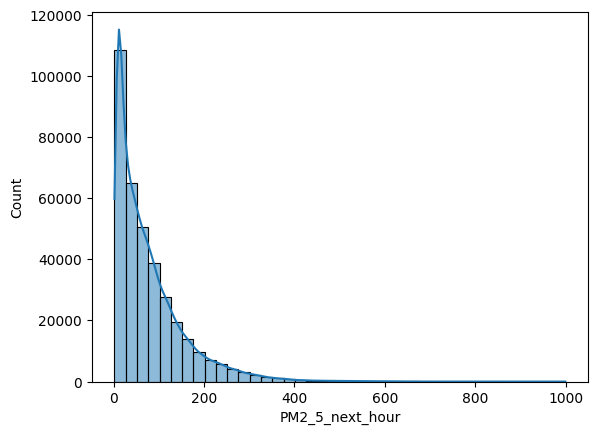

In [84]:
# Investigate dist of target variable

sns.histplot(target, bins=40, kde=True)
plt.show()

Log transformations can help distribution/variance

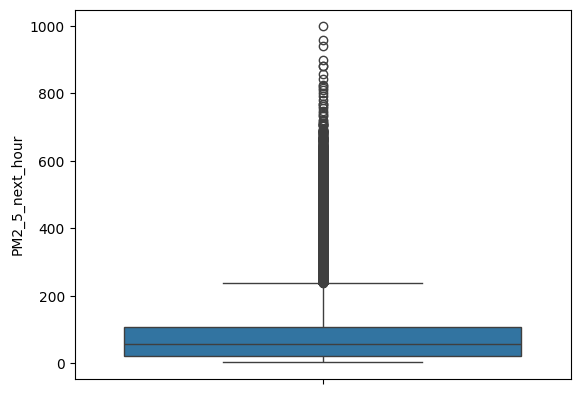

In [85]:
sns.boxplot(y = target)
plt.show()

In [86]:
var_df.describe().round(4)

,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,PM2_5_next_hour
count,360954.0000,360954.0000,360954.0000,360954.0000,359032.0000,356291.0000,353433.0000,345122.0000,352455.0000,360777.0000,360776.0000,360772.0000,360780.0000,360779.0000,360954.0000
mean,2014.4258,6.3699,15.7493,11.4932,103.5245,16.3760,49.4879,1184.5083,60.8432,14.4727,1009.7566,3.2827,0.0668,1.7346,78.0440
std,1.0522,3.2778,8.8036,6.9347,88.9152,22.3955,34.3746,1085.4396,58.1102,11.3764,10.3466,13.8303,0.8321,1.2505,77.7779
min,2013.0000,1.0000,1.0000,0.0000,2.0000,0.2856,1.0265,100.0000,0.2142,-19.9000,982.4000,-43.4000,0.0000,0.0000,2.0000
25%,2014.0000,4.0000,8.0000,5.0000,37.0000,3.0000,23.0000,500.0000,13.0000,4.4000,1001.4000,-8.1000,0.0000,0.9000,21.0000
50%,2014.0000,6.0000,16.0000,11.0000,82.0000,7.7112,42.0000,900.0000,49.0000,16.1000,1009.0000,4.5000,0.0000,1.4000,55.0000
75%,2015.0000,9.0000,23.0000,18.0000,144.0000,20.0000,69.0000,1500.0000,86.0000,23.9000,1017.8000,15.8000,0.0000,2.2000,108.0000
max,2016.0000,12.0000,31.0000,23.0000,999.0000,500.0000,290.0000,10000.0000,1071.0000,41.6000,1042.8000,29.1000,72.5000,13.2000,999.0000


# 1.1 Correlation Analysis

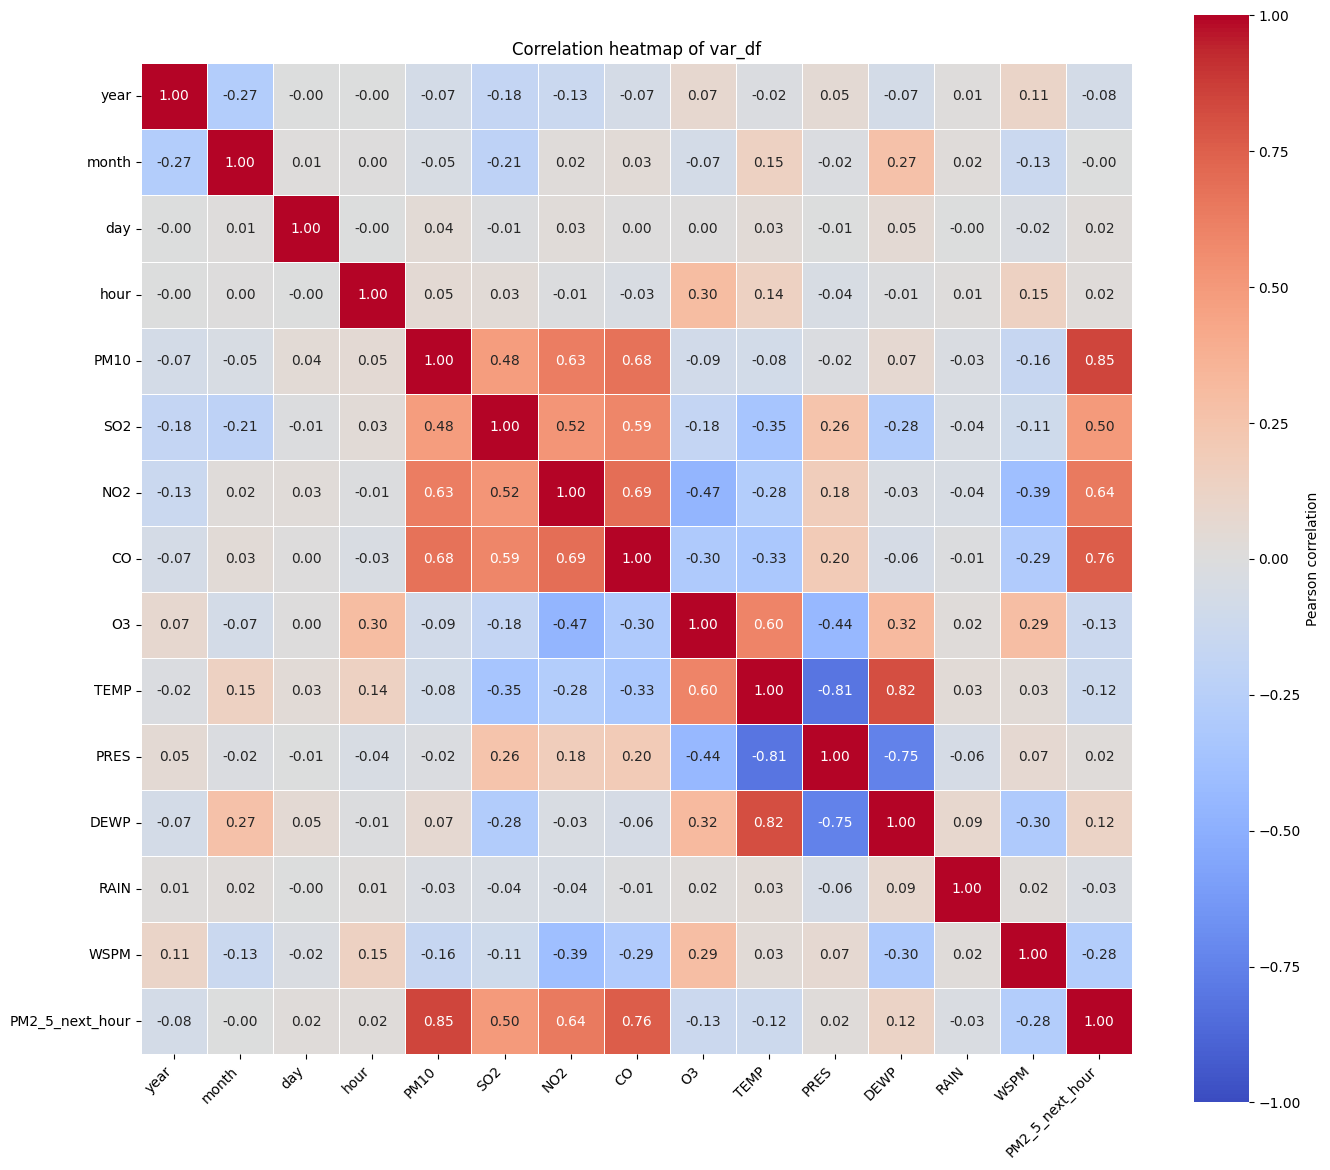

In [87]:
# Pearson correlations for numeric variables (including the target).
# Missing values are excluded pairwise; nonnumeric columns are omitted.
corr_matrix = var_df.corr(method="pearson", numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}, ax=ax
)
ax.set_title("Correlation heatmap of var_df")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 1.1.1 Correlation ratio: categorical versus continuous variables

The correlation ratio **eta** measures how much numerical values differ in their means across categories, such as wind directions. It is the square root of between-group variation divided by total variation. Eta ranges from **0** (equal group means) to **1** (all observed variation lies between groups). **Eta squared** is the fraction of observed numerical variance accounted for by category membership; it does not establish causality or statistical significance. Eta has no positive/negative sign, and zero does not rule out differences in group distributions beyond their means.

The heatmap compares `wd` and `station` with the sensor measurements and target. Calendar fields are excluded. Missing/nonfinite observations are excluded separately for each pair. Constant numerical variables return NaN. This is descriptive analysis of the full `var_df`, matching the Pearson plot above; use only the training partition if these results guide feature selection.

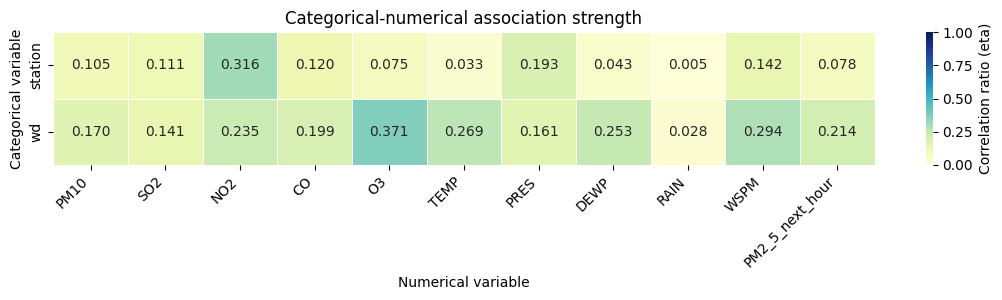

In [88]:
from IPython.display import display


def correlation_ratio(categories, values):
    """Return eta and pair count, excluding missing categories/nonfinite values."""
    pairs = pd.DataFrame({"category": categories, "value": values})
    pairs["value"] = pd.to_numeric(pairs["value"], errors="coerce").replace(
        [np.inf, -np.inf], np.nan
    )
    pairs = pairs.dropna(subset=["category", "value"])
    n = len(pairs)
    if n == 0:
        return np.nan, n
    overall_mean = pairs["value"].mean()
    total_ss = ((pairs["value"] - overall_mean) ** 2).sum()
    if total_ss == 0:
        return np.nan, n  # Undefined when the numerical variable is constant.
    groups = pairs.groupby("category", observed=True)["value"].agg(["count", "mean"])
    between_ss = (groups["count"] * (groups["mean"] - overall_mean) ** 2).sum()
    return float(np.sqrt(np.clip(between_ss / total_ss, 0, 1))), n


# Use the same original data as the Pearson plot; no imputation is needed.
nominal_columns = var_df.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns
# Calendar fields are numeric-coded time variables, rather than continuous sensors.
continuous_columns = var_df.select_dtypes(include="number").columns.difference(
    ["year", "month", "day", "hour"], sort=False
)
eta_records = []
for nominal in nominal_columns:
    for continuous in continuous_columns:
        eta, n = correlation_ratio(var_df[nominal], var_df[continuous])
        eta_records.append({
            "categorical": nominal, "continuous": continuous,
            "eta": eta, "eta_squared": eta ** 2, "n_pairs": n,
        })

correlation_ratio_results = pd.DataFrame(
    eta_records, columns=["categorical", "continuous", "eta", "eta_squared", "n_pairs"]
)
if not correlation_ratio_results.empty:
    eta_matrix = correlation_ratio_results.pivot(
        index="categorical", columns="continuous", values="eta"
    ).reindex(index=nominal_columns, columns=continuous_columns)
    fig, ax = plt.subplots(figsize=(max(10, len(continuous_columns)),
                                    max(3, 0.8 * len(nominal_columns) + 1.5)))
    sns.heatmap(eta_matrix, annot=True, fmt=".3f", cmap="YlGnBu",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": "Correlation ratio (eta)"}, ax=ax)
    ax.set_title("Categorical-numerical association strength")
    ax.set_xlabel("Numerical variable")
    ax.set_ylabel("Categorical variable")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

else:
    print("No categorical-numerical pairs available.")

We see that there is low positive correlation associated for both categorical variables to the continuous

# 1.2 Variable Distributions

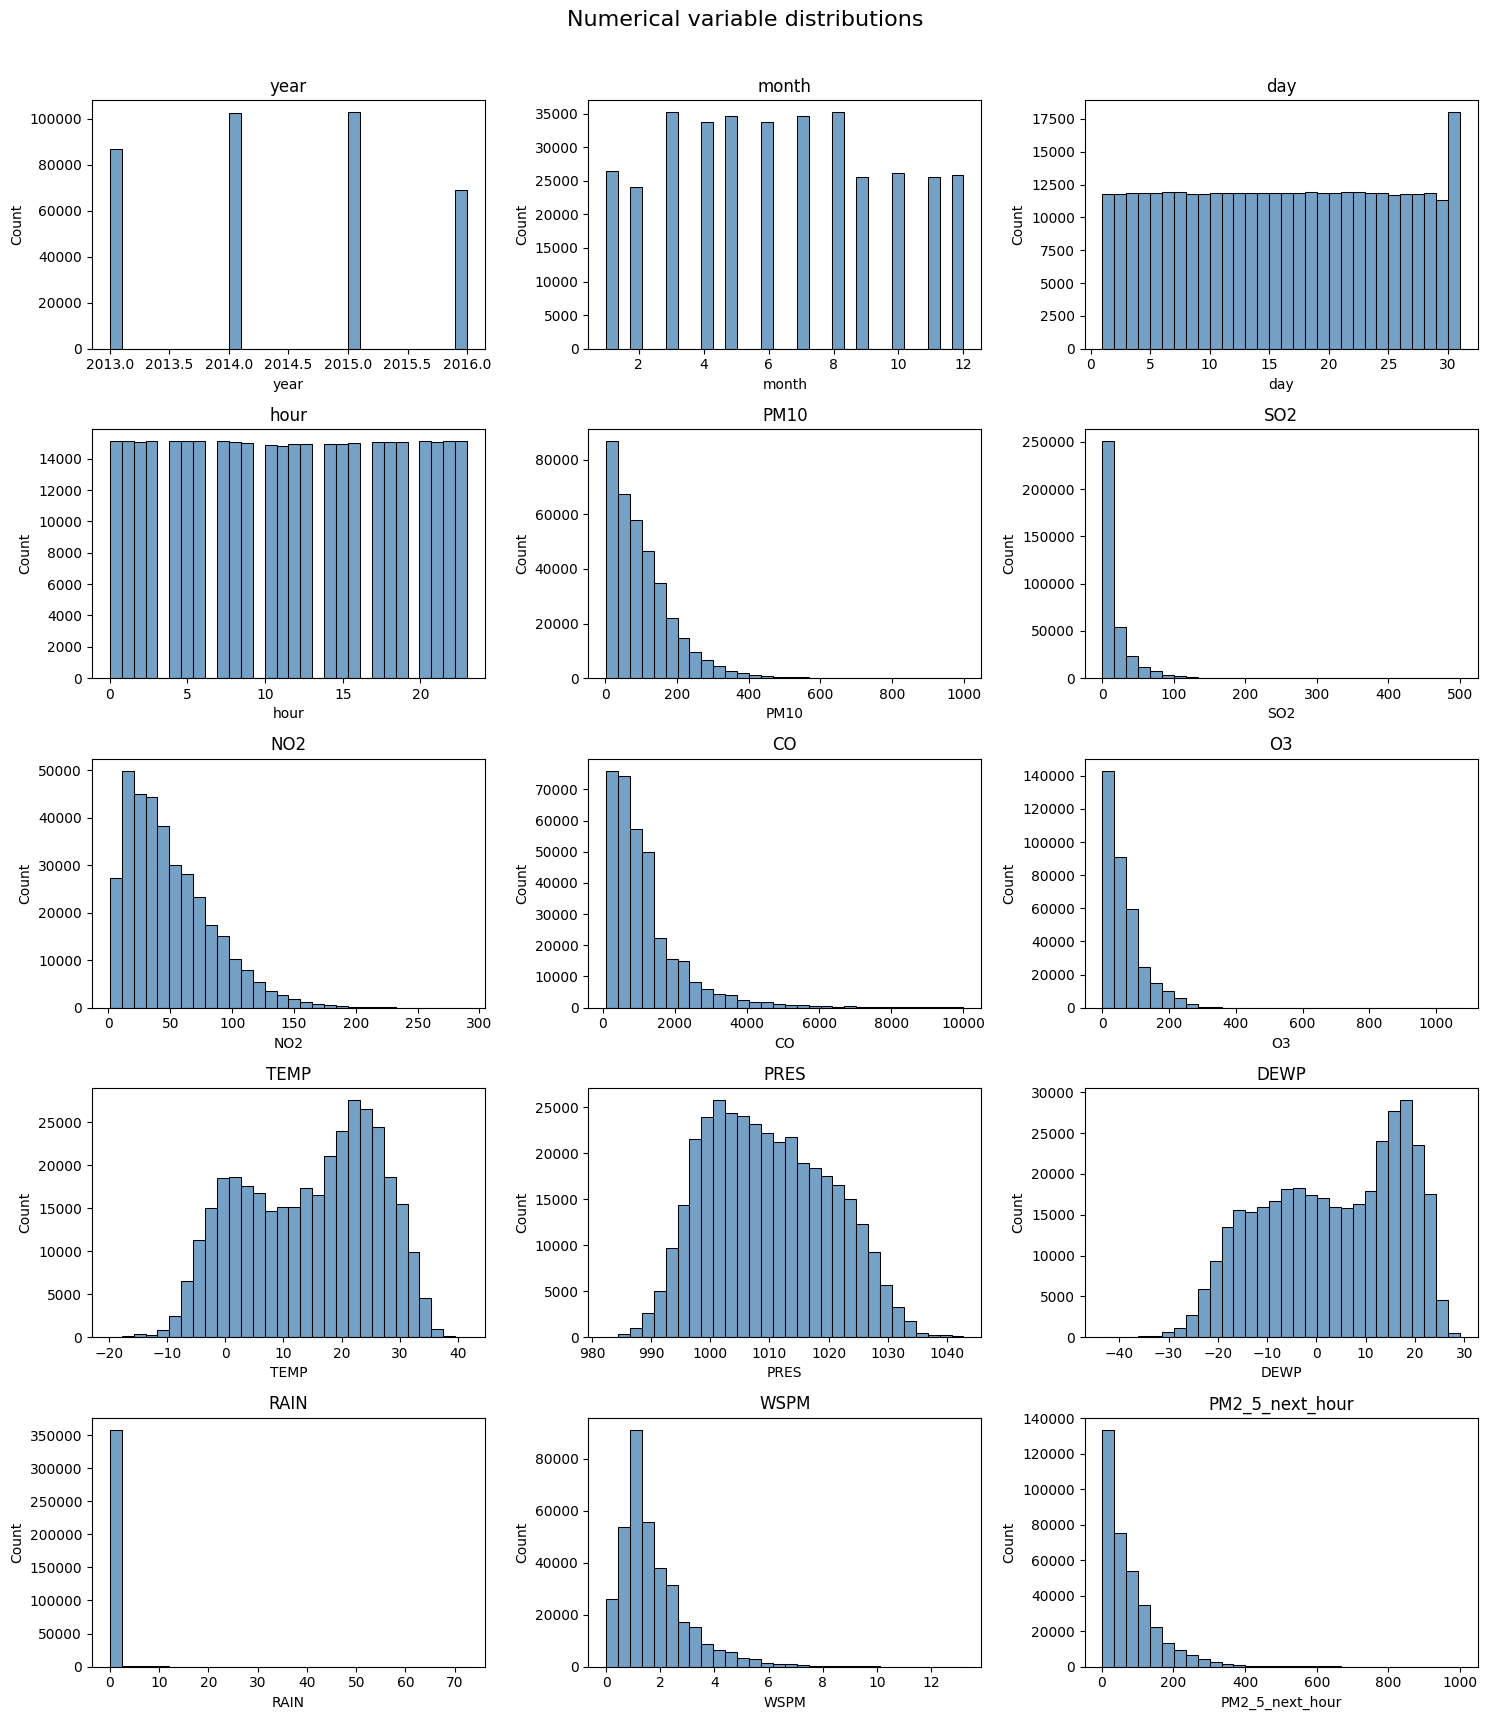

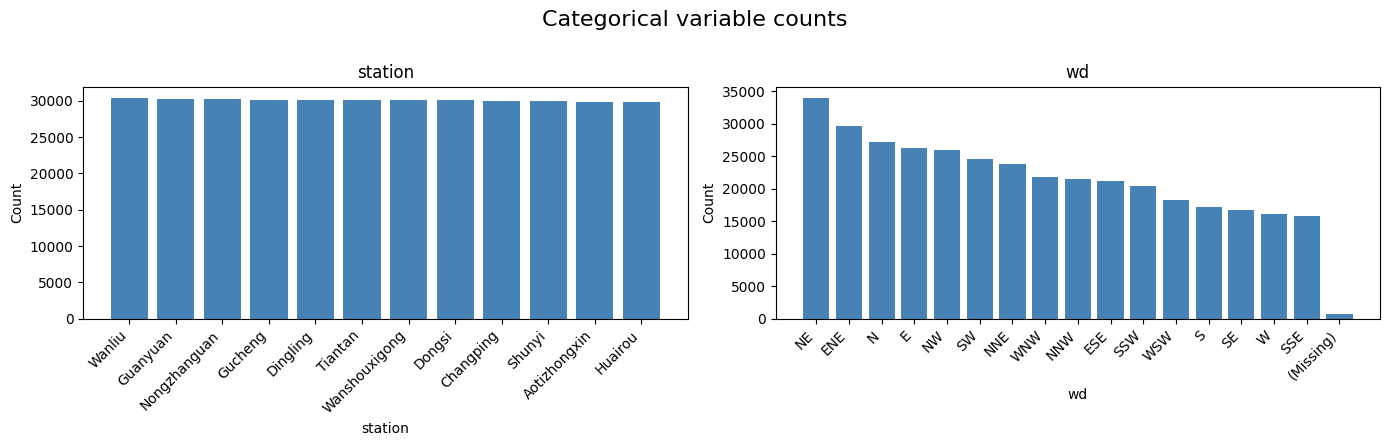

In [89]:
def plot_numeric_distributions(data, bins=30, ncols=3):
    """Plot a histogram for every numeric column; omit missing/infinite values."""
    columns = data.select_dtypes(include="number").columns
    if len(columns) == 0:
        print("No numerical variables to plot.")
        return
    if ncols < 1:
        raise ValueError("ncols must be at least 1.")

    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
    for ax, column in zip(axes.flat, columns):
        values = data[column].replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            ax.text(0.5, 0.5, "No finite values", ha="center", transform=ax.transAxes)
        else:
            sns.histplot(values, bins=bins, ax=ax, color="steelblue")
        ax.set_title(str(column))
        ax.set_xlabel(str(column))
        ax.set_ylabel("Count")
    for ax in list(axes.flat)[len(columns):]:
        ax.set_visible(False)
    fig.suptitle("Numerical variable distributions", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()
    return fig, axes


def plot_categorical_counts(data, ncols=2):
    """Plot all category counts for object, string, category, and boolean columns."""
    columns = data.select_dtypes(include=["object", "string", "category", "bool"]).columns
    if len(columns) == 0:
        print("No categorical variables to plot.")
        return
    if ncols < 1:
        raise ValueError("ncols must be at least 1.")

    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), squeeze=False)
    for ax, column in zip(axes.flat, columns):
        counts = data[column].value_counts(dropna=True)
        counts = counts[counts > 0]
        labels = [str(value) for value in counts.index]
        heights = counts.tolist()
        missing = int(data[column].isna().sum())
        if missing:
            labels.append("(Missing)")
            heights.append(missing)
        ax.bar(range(len(labels)), heights, color="steelblue")
        ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
        ax.set_title(str(column))
        ax.set_xlabel(str(column))
        ax.set_ylabel("Count")
    for ax in list(axes.flat)[len(columns):]:
        ax.set_visible(False)
    fig.suptitle("Categorical variable counts", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()
    return fig, axes


# Plot every variable using its dtype; numeric-coded categories remain numeric.
_ = plot_numeric_distributions(var_df)
_ = plot_categorical_counts(var_df)


Observe that the variables PM10, SO2, NO2, CO, O3 are heavily right skewed --> log transformations, or alternatives should be considered

Current feature engineering plans

* Log transformations on NO2, CO, O3 WSPM, PM_2_5_next_hour

* RAIN turn into indicator variable 0/1

* Standardise on TEMP, PRES, DEWP

We see bimodal dist on TEMP and DEWP --> observe the seasonal trends

## 1.2.1 Investigating seasonal trends in temperature and dew point

Interpretation: Look for a repeating annual cycle and separation between winter and summer distributions. If individual seasonal distributions are less bimodal than the pooled distribution, that supports seasonality as an explanation, but does not prove it. Spring/autumn can still span a broad range. Counts in the summary help identify unequal coverage; pooled station observations can also affect these patterns.
Season definitions below assume Northern Hemisphere data: winter Decâ€“Feb, spring Marâ€“May, summer Junâ€“Aug, autumn Sepâ€“Nov.

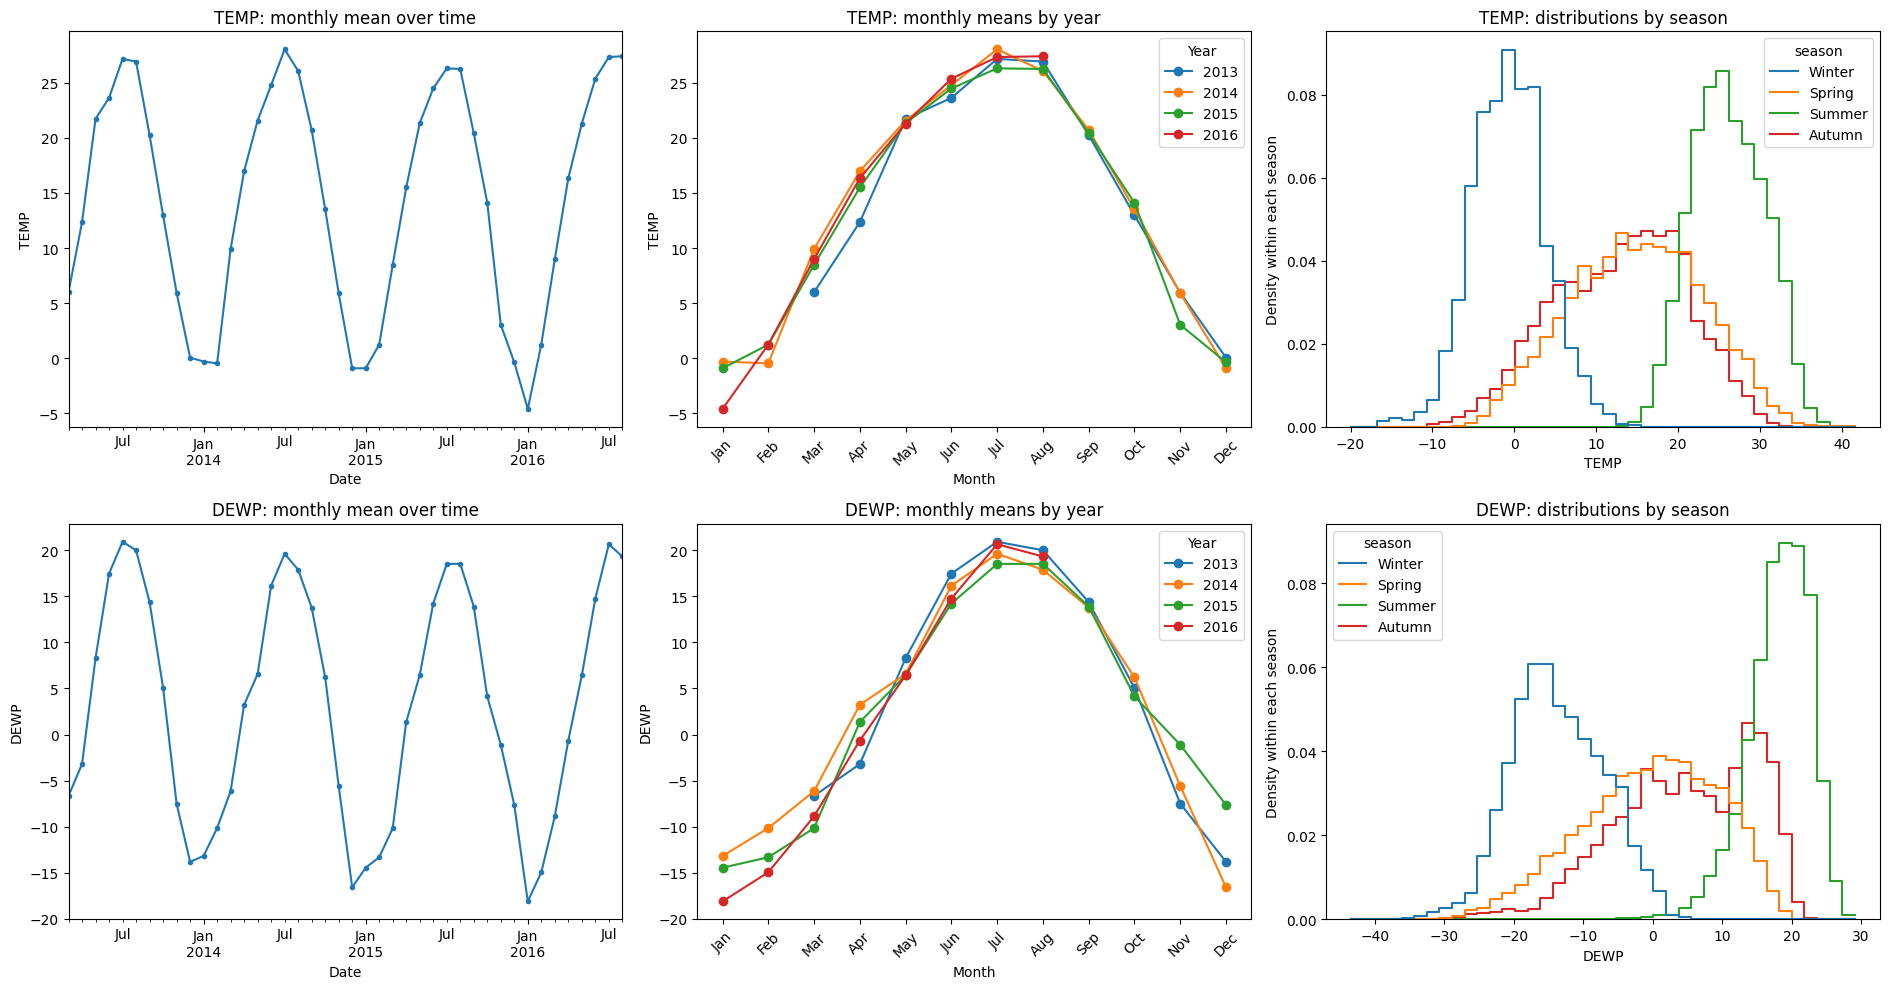

TEMP                        DEWP                    
         count   mean median   std   count   mean median   std
season                                                        
Winter   76161  -0.58   -0.6  4.48   76161 -13.60  -14.1  6.59
Spring  103698  14.98   15.1  8.05  103698  -0.34    0.5  9.75
Summer  103656  26.14   25.9  4.34  103653  18.18   18.7  4.50
Autumn   77262  12.98   13.7  7.97   77260   4.80    5.5  9.86

In [90]:
def analyze_seasonality(data, variables=("TEMP", "DEWP")):
    """Compare monthly trends and seasonal distributions using calendar dates.

    Uses Northern Hemisphere seasons. Rows/stations are pooled; counts expose
    unequal coverage. Monthly means are descriptive, not causal estimates.
    """
    required = ["year", "month", "day", *variables]
    missing = [column for column in required if column not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    work = data[required].copy()
    work["date"] = pd.to_datetime(work[["year", "month", "day"]], errors="coerce")
    work = work.dropna(subset=["date"])
    if work.empty:
        raise ValueError("No valid dates to analyze.")
    for variable in variables:
        work[variable] = pd.to_numeric(work[variable], errors="coerce").replace(
            [np.inf, -np.inf], np.nan
        )
    work["month"] = work["date"].dt.month
    seasons = ["Winter", "Spring", "Summer", "Autumn"]
    season_map = {12: "Winter", 1: "Winter", 2: "Winter",
                  3: "Spring", 4: "Spring", 5: "Spring",
                  6: "Summer", 7: "Summer", 8: "Summer",
                  9: "Autumn", 10: "Autumn", 11: "Autumn"}
    work["season"] = pd.Categorical(work["month"].map(season_map),
                                     categories=seasons, ordered=True)
    monthly = work.set_index("date")[list(variables)].resample("MS").mean()
    summary = work.groupby("season", observed=False)[list(variables)].agg(
        ["count", "mean", "median", "std"]
    )
    fig, axes = plt.subplots(len(variables), 3, figsize=(19, 5 * len(variables)),
                             squeeze=False)
    months = list(range(1, 13))
    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    for row, variable in enumerate(variables):
        monthly[variable].plot(ax=axes[row, 0], marker="o", markersize=3)
        axes[row, 0].set_title(f"{variable}: monthly mean over time")
        axes[row, 0].set_xlabel("Date")
        axes[row, 0].set_ylabel(variable)

        # Each line represents one year, revealing repeatable seasonal cycles.
        by_year = work.groupby(["year", "month"])[variable].mean().unstack("year")
        by_year.reindex(months).plot(ax=axes[row, 1], marker="o")
        axes[row, 1].set_xticks(months, month_labels, rotation=45)
        axes[row, 1].set_title(f"{variable}: monthly means by year")
        axes[row, 1].set_xlabel("Month")
        axes[row, 1].set_ylabel(variable)
        axes[row, 1].legend(title="Year")

        sns.histplot(data=work, x=variable, hue="season", hue_order=seasons,
                     bins=40, stat="density", common_norm=False,
                     element="step", fill=False, ax=axes[row, 2])
        axes[row, 2].set_title(f"{variable}: distributions by season")
        axes[row, 2].set_ylabel("Density within each season")
    fig.tight_layout()
    plt.show()
    return monthly, summary


monthly_trends, seasonal_summary = analyze_seasonality(var_df)
display(seasonal_summary.round(2))


In [1]:
# Chronological holdout: approximately 80% train, 20% validation.
# Keep all stations at a given timestamp in the same partition.
ordered_df = df.copy()
ordered_df["observation_timestamp"] = pd.to_datetime(
    ordered_df["observation_timestamp"], errors="raise"
)
if ordered_df["observation_timestamp"].isna().any():
    raise ValueError("Timestamps must not be missing for a chronological split.")
ordered_df = ordered_df.sort_values("observation_timestamp", kind="stable")

# Choose the timestamp boundary closest to 80% of rows.
timestamp_counts = ordered_df.groupby("observation_timestamp", sort=True).size()
if len(timestamp_counts) < 2:
    raise ValueError("At least two distinct timestamps are required.")
candidate_sizes = timestamp_counts.cumsum().iloc[:-1]
boundary_index = (candidate_sizes - 0.8 * len(ordered_df)).abs().to_numpy().argmin()
validation_start = timestamp_counts.index[boundary_index + 1]

train_df = ordered_df.loc[
    ordered_df["observation_timestamp"] < validation_start
].copy()
val_df = ordered_df.loc[
    ordered_df["observation_timestamp"] >= validation_start
].copy()

target_column = "PM2_5_next_hour"
feature_columns = [
    column for column in var_df.columns if column != target_column
]
X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()
X_val = val_df[feature_columns].copy()
y_val = val_df[target_column].copy()

assert len(train_df) + len(val_df) == len(df)
assert train_df["observation_timestamp"].max() < val_df["observation_timestamp"].min()
assert X_train.index.equals(y_train.index)
assert X_val.index.equals(y_val.index)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation"],
    "rows": [len(train_df), len(val_df)],
    "fraction": [len(train_df) / len(df), len(val_df) / len(df)],
    "start": [train_df["observation_timestamp"].min(),
              val_df["observation_timestamp"].min()],
    "end": [train_df["observation_timestamp"].max(),
            val_df["observation_timestamp"].max()],
})
display(split_summary)
# Fit imputers, encoders, and scalers on X_train only, then transform X_val.


,split,rows,fraction,start,end
0,Train,288762,0.799997,2013-03-01 00:00:00,2015-12-20 00:00:00
1,Validation,72192,0.200003,2015-12-20 01:00:00,2016-08-31 22:00:00


# 2.0 Preprocessing

## 2.1 Missing Values Remedy

Fill missing TEMP and DEWP with their respective training means for the observation's season: winter Dec-Feb, spring Mar-May, summer Jun-Aug, autumn Sep-Nov. These features stay in their original units.

For other numeric features with missing training values (PM10, SO2, NO2, CO, O3, PRES, RAIN and WSPM), apply `np.log1p(x)` to all observed values, then fill missing values with the training mean in log space. `log1p` accommodates zero rainfall and wind speed. The split above uses original rainfall amounts. Transformed output columns are named `log_[X]`, for example `log_PM10` and `log_RAIN`.

All statistics and column selection are fitted on `X_train` only and reused for validation. Use `X_train_preprocessed` and `X_val_preprocessed` for subsequent modelling. The original splits and targets are preserved; categorical missing values (such as `wd`) still need separate preprocessing. `preprocess_features` also accepts future test features with the same columns. Rerun the fitting cell if the training split changes.

In [2]:
# Fit preprocessing statistics on the training partition only.
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
seasonal_columns = ["TEMP", "DEWP"]
train_seasons = X_train["month"].map(season_map)
if train_seasons.isna().any():
    raise ValueError("Training months must be integers from 1 to 12.")
seasonal_means = (
    X_train[seasonal_columns]
    .groupby(train_seasons.rename("season"))
    .mean()
    .reindex(["Winter", "Spring", "Summer", "Autumn"])
)
if seasonal_means.isna().any().any():
    raise ValueError("Each season needs observed training TEMP and DEWP values.")

# Select other numeric features with missing training values; never use y.
numeric_candidates = X_train.select_dtypes(include="number").columns.difference(
    seasonal_columns, sort=False
)
log_columns = [c for c in numeric_candidates if X_train[c].isna().any()]
log_column_names = {column: f"log_{column}" for column in log_columns}
if X_train[log_columns].lt(0).any().any():
    raise ValueError("Expected nonnegative values for log1p features.")
log_means = np.log1p(X_train[log_columns].astype(float)).mean()
if not np.isfinite(log_means.to_numpy()).all():
    raise ValueError("Each log feature needs finite observed training values.")


def preprocess_features(features):
    """Apply the fitted training statistics to train, validation, or test rows."""
    result = features.copy()
    seasons = result["month"].map(season_map)
    if seasons.isna().any():
        raise ValueError("Months must be integers from 1 to 12.")
    for column in seasonal_columns:
        result[column] = result[column].fillna(seasons.map(seasonal_means[column]))
    if result[log_columns].lt(0).any().any():
        raise ValueError("Expected nonnegative values for log1p features.")
    result[log_columns] = np.log1p(result[log_columns].astype(float)).fillna(log_means)
    if not np.isfinite(result[seasonal_columns + log_columns].to_numpy()).all():
        raise ValueError("Preprocessed features contain missing or infinite values.")
    return result.rename(columns=log_column_names)


X_train_preprocessed = preprocess_features(X_train)
X_val_preprocessed = preprocess_features(X_val)

print("Seasonal imputation means (training data):")
display(seasonal_means)
print("Log-space imputation means (training data):")
display(log_means.rename(index=log_column_names).rename("mean_log1p").to_frame())
display(pd.DataFrame({
    "train_missing_before": X_train.isna().sum().rename(index=log_column_names),
    "train_missing_after": X_train_preprocessed.isna().sum(),
    "validation_missing_before": X_val.isna().sum().rename(index=log_column_names),
    "validation_missing_after": X_val_preprocessed.isna().sum(),
}))

Seasonal imputation means (training data):
Log-space imputation means (training data):


,TEMP,DEWP
season,,
Winter,-0.135962,-13.057683
Spring,14.804744,-0.097894
Summer,25.954461,18.150264
Autumn,12.980921,4.795016


,mean_log1p
log_PM10,4.289988
log_SO2,2.349170
log_NO2,3.700852
log_CO,6.787493
log_O3,3.454274
log_PRES,6.918458
log_RAIN,0.025388
log_WSPM,0.893516


,train_missing_before,train_missing_after,validation_missing_before,validation_missing_after
station,0,0,0,0
year,0,0,0,0
month,0,0,0,0
day,0,0,0,0
hour,0,0,0,0
log_PM10,1371,0,551,0
log_SO2,3879,0,784,0
log_NO2,6466,0,1055,0
log_CO,14765,0,1067,0
log_O3,7151,0,1348,0


## 2.2 Dropping rows

In [93]:
# Missing wind direction across the full train.csv (before splitting).
total_rows = len(df)
missing_wd = df["wd"].isna().sum()
missing_wd_fraction = missing_wd / total_rows if total_rows else np.nan

print(f"Missing wd: {missing_wd_fraction:.4%}")

Missing wd: 0.2197%


Less than 1% + no plausible method of imputation + low correlation ratio to other variables suggests less strenght in aiding prediction --> decided to drop these missing rows for wd

In [3]:
# Drop missing wind directions from both modelling partitions.

X_train_preprocessed = X_train_preprocessed.dropna(subset=["wd"]).copy()
X_val_preprocessed = X_val_preprocessed.dropna(subset=["wd"]).copy()
y_train_preprocessed = y_train.loc[X_train_preprocessed.index].copy()
y_val_preprocessed = y_val.loc[X_val_preprocessed.index].copy()


## 2.3 Demeaning and numerical/dummy interactions

`make_interactions` follows the example: demean continuous variables using training means, leave 0/1 dummies uncentred, and multiply distinct pairs. It returns main effects, a separate interaction DataFrame, and fitted settings for validation/test data. Existing dummies can be supplied through `dummy_columns`.

Here `station` and `wd` are dummy encoded using training categories, dropping the first sorted level as reference. Numerical-numerical, numerical-dummy and dummy-dummy products are generated. Products of two levels from the same categorical field are omitted because they are always zero. Missing or unseen categories raise an error. Calendar fields are retained without interactions. Log features are demeaned in log space. Interaction columns use float32 to reduce memory usage.

In a linear model with main effects and interactions, numerical main-effect coefficients describe slopes at the other numerical features' training means and the reference categories. Dummy main effects compare categories at those means and references. Products need not have zero mean. The expanded feature set can overfit; compare validation performance.

Use `X_train_interactions` with `y_train_preprocessed` and `X_val_interactions` with `y_val_preprocessed`. The input datasets are preserved. Rerun this section after changing preprocessing or the split.

In [4]:
from itertools import combinations


def make_interactions(data, continuous_columns=None, categorical_columns=(),
                      dummy_columns=(), fitted=None):
    """Return main effects, pairwise interactions and reusable training settings.

    Demean continuous columns; leave existing 0/1 dummies uncentred.
    Encode categoricals with the first sorted training level as reference.
    Unselected columns are retained without interactions.
    """
    if fitted is None:
        if continuous_columns is None:
            raise ValueError("Specify continuous_columns when fitting.")
        selected = list(continuous_columns) + list(categorical_columns) + list(dummy_columns)
        if len(selected) != len(set(selected)):
            raise ValueError("Feature lists must not overlap.")
        fitted = dict(
            continuous=list(continuous_columns), categorical=list(categorical_columns),
            dummy=list(dummy_columns), columns=data.columns.tolist(),
            means=data[list(continuous_columns)].mean(),
            levels={c: sorted(data[c].dropna().unique().tolist()) for c in categorical_columns},
        )
    continuous = fitted["continuous"]
    categorical = fitted["categorical"]
    dummy = fitted["dummy"]
    work = data.loc[:, fitted["columns"]].copy()
    centered = work[continuous].subtract(fitted["means"], axis="columns")
    if not np.isfinite(centered.to_numpy()).all():
        raise ValueError("Continuous values and training means must be finite.")
    centered = centered.rename(columns={c: f"{c}_demean" for c in continuous})
    parts = [centered]
    origins = {c: c for c in centered.columns}
    for column in dummy:
        if not work[column].isin([0, 1]).all():
            raise ValueError(f"{column} must contain only 0/1 values.")
        parts.append(work[[column]].astype("int8"))
        origins[column] = column
    for column in categorical:
        levels = fitted["levels"][column]
        if not levels or not work[column].isin(levels).all():
            raise ValueError(f"{column} contains missing or unseen categories.")
        encoded = pd.get_dummies(
            pd.Series(pd.Categorical(work[column], categories=levels), index=work.index),
            prefix=column, drop_first=True, dtype="int8"
        )
        parts.append(encoded)
        origins.update({name: column for name in encoded.columns})
    active = pd.concat(parts, axis=1)
    main_effects = pd.concat([work.drop(columns=continuous + categorical + dummy), active], axis=1)
    if not main_effects.columns.is_unique:
        raise ValueError("Generated column names overlap existing names.")
    # Skip products of mutually exclusive levels from the same categorical field.
    # Float32 reduces the memory required by the expanded feature set.
    interactions = pd.DataFrame({
        f"{left}_x_{right}": (active[left] * active[right]).astype("float32")
        for left, right in combinations(active.columns, 2)
        if origins[left] != origins[right]
    }, index=work.index)
    return main_effects, interactions, fitted


continuous_columns = X_train_preprocessed.select_dtypes(include="number").columns.difference(
    ["year", "month", "day", "hour"], sort=False
).tolist()
X_train_main_effects, train_interactions, interaction_settings = make_interactions(
    X_train_preprocessed, continuous_columns=continuous_columns,
    categorical_columns=["station", "wd"],
)
X_val_main_effects, val_interactions, _ = make_interactions(
    X_val_preprocessed, fitted=interaction_settings
)

# Include main effects alongside the interaction terms when modelling.
X_train_interactions = pd.concat([X_train_main_effects, train_interactions], axis=1)
X_val_interactions = pd.concat([X_val_main_effects, val_interactions], axis=1)
assert X_train_interactions.index.equals(y_train_preprocessed.index)
assert X_val_interactions.index.equals(y_val_preprocessed.index)
assert X_train_interactions.columns.equals(X_val_interactions.columns)
print(f"Created {train_interactions.shape[1]} interaction terms.")
display(train_interactions.head())

Created 470 interaction terms.


,log_PM10_demean_x_log_SO2_demean,log_PM10_demean_x_log_NO2_demean,log_PM10_demean_x_log_CO_demean,log_PM10_demean_x_log_O3_demean,log_PM10_demean_x_TEMP_demean,log_PM10_demean_x_log_PRES_demean,log_PM10_demean_x_DEWP_demean,log_PM10_demean_x_log_RAIN_demean,log_PM10_demean_x_log_WSPM_demean,log_PM10_demean_x_station_Changping,log_PM10_demean_x_station_Dingling,log_PM10_demean_x_station_Dongsi,log_PM10_demean_x_station_Guanyuan,log_PM10_demean_x_station_Gucheng,log_PM10_demean_x_station_Huairou,log_PM10_demean_x_station_Nongzhanguan,log_PM10_demean_x_station_Shunyi,log_PM10_demean_x_station_Tiantan,log_PM10_demean_x_station_Wanliu,log_PM10_demean_x_station_Wanshouxigong,log_PM10_demean_x_wd_ENE,log_PM10_demean_x_wd_ESE,log_PM10_demean_x_wd_N,log_PM10_demean_x_wd_NE,log_PM10_demean_x_wd_NNE,log_PM10_demean_x_wd_NNW,log_PM10_demean_x_wd_NW,log_PM10_demean_x_wd_S,log_PM10_demean_x_wd_SE,log_PM10_demean_x_wd_SSE,log_PM10_demean_x_wd_SSW,log_PM10_demean_x_wd_SW,log_PM10_demean_x_wd_W,log_PM10_demean_x_wd_WNW,log_PM10_demean_x_wd_WSW,log_SO2_demean_x_log_NO2_demean,log_SO2_demean_x_log_CO_demean,log_SO2_demean_x_log_O3_demean,log_SO2_demean_x_TEMP_demean,log_SO2_demean_x_log_PRES_demean,log_SO2_demean_x_DEWP_demean,log_SO2_demean_x_log_RAIN_demean,log_SO2_demean_x_log_WSPM_demean,log_SO2_demean_x_station_Changping,log_SO2_demean_x_station_Dingling,log_SO2_demean_x_station_Dongsi,log_SO2_demean_x_station_Guanyuan,log_SO2_demean_x_station_Gucheng,log_SO2_demean_x_station_Huairou,log_SO2_demean_x_station_Nongzhanguan,log_SO2_demean_x_station_Shunyi,log_SO2_demean_x_station_Tiantan,log_SO2_demean_x_station_Wanliu,log_SO2_demean_x_station_Wanshouxigong,log_SO2_demean_x_wd_ENE,log_SO2_demean_x_wd_ESE,log_SO2_demean_x_wd_N,log_SO2_demean_x_wd_NE,log_SO2_demean_x_wd_NNE,log_SO2_demean_x_wd_NNW,log_SO2_demean_x_wd_NW,log_SO2_demean_x_wd_S,log_SO2_demean_x_wd_SE,log_SO2_demean_x_wd_SSE,log_SO2_demean_x_wd_SSW,log_SO2_demean_x_wd_SW,log_SO2_demean_x_wd_W,log_SO2_demean_x_wd_WNW,log_SO2_demean_x_wd_WSW,log_NO2_demean_x_log_CO_demean,log_NO2_demean_x_log_O3_demean,log_NO2_demean_x_TEMP_demean,log_NO2_demean_x_log_PRES_demean,log_NO2_demean_x_DEWP_demean,log_NO2_demean_x_log_RAIN_demean,log_NO2_demean_x_log_WSPM_demean,log_NO2_demean_x_station_Changping,log_NO2_demean_x_station_Dingling,log_NO2_demean_x_station_Dongsi,log_NO2_demean_x_station_Guanyuan,log_NO2_demean_x_station_Gucheng,log_NO2_demean_x_station_Huairou,log_NO2_demean_x_station_Nongzhanguan,log_NO2_demean_x_station_Shunyi,log_NO2_demean_x_station_Tiantan,log_NO2_demean_x_station_Wanliu,log_NO2_demean_x_station_Wanshouxigong,log_NO2_demean_x_wd_ENE,log_NO2_demean_x_wd_ESE,log_NO2_demean_x_wd_N,log_NO2_demean_x_wd_NE,log_NO2_demean_x_wd_NNE,log_NO2_demean_x_wd_NNW,log_NO2_demean_x_wd_NW,log_NO2_demean_x_wd_S,log_NO2_demean_x_wd_SE,log_NO2_demean_x_wd_SSE,log_NO2_demean_x_wd_SSW,log_NO2_demean_x_wd_SW,log_NO2_demean_x_wd_W,log_NO2_demean_x_wd_WNW,log_NO2_demean_x_wd_WSW,log_CO_demean_x_log_O3_demean,log_CO_demean_x_TEMP_demean,log_CO_demean_x_log_PRES_demean,log_CO_demean_x_DEWP_demean,log_CO_demean_x_log_RAIN_demean,log_CO_demean_x_log_WSPM_demean,log_CO_demean_x_station_Changping,log_CO_demean_x_station_Dingling,log_CO_demean_x_station_Dongsi,log_CO_demean_x_station_Guanyuan,log_CO_demean_x_station_Gucheng,log_CO_demean_x_station_Huairou,log_CO_demean_x_station_Nongzhanguan,log_CO_demean_x_station_Shunyi,log_CO_demean_x_station_Tiantan,log_CO_demean_x_station_Wanliu,log_CO_demean_x_station_Wanshouxigong,log_CO_demean_x_wd_ENE,log_CO_demean_x_wd_ESE,log_CO_demean_x_wd_N,log_CO_demean_x_wd_NE,log_CO_demean_x_wd_NNE,log_CO_demean_x_wd_NNW,log_CO_demean_x_wd_NW,log_CO_demean_x_wd_S,log_CO_demean_x_wd_SE,log_CO_demean_x_wd_SSE,log_CO_demean_x_wd_SSW,log_CO_demean_x_wd_SW,log_CO_demean_x_wd_W,log_CO_demean_x_wd_WNW,log_CO_demean_x_wd_WSW,log_O3_demean_x_TEMP_demean,log_O3_demean_x_log_PRES_demean,log_O3_demean_x_DEWP_demean,log_O3_demean_x_log_RAIN_demean,log_O3_demean_x_log_WSPM_demean,log

## 3. Linear regression, XGBoost and neural network comparison

All models use the same chronological train/validation split, retained wind-direction rows, original target units, encoded main effects and interactions. OLS compares main effects, two training-only correlation screens (absolute Pearson thresholds 0.90 and 0.98), and all interactions. Screens retain main effects so retained products have their constituent terms. Correlation screening is heuristic and does not eliminate all multicollinearity. Constants are removed and scaling is fitted only on training rows for OLS numerical stability.

AIC and BIC are Gaussian training-fit criteria, not backtesting scores. Lower is better among these OLS candidates on the same target and rows. Parameter counts use effective design rank plus intercept and residual variance. Temporal dependence and repeated stations weaken the independent-error interpretation of these criteria. AIC/BIC choices are recorded before validation scoring; RMSE, MAE and R-squared on the later holdout provide the chronological backtest. This is one holdout, not rolling cross-validation; earlier full-data exploratory analysis also means it is not a pristine untouched test.

XGBoost receives all features with fixed regularised settings and no tuning/early stopping on this holdout. Trees may leave features unused, but do not guarantee removal of every unnecessary variable. Conventional OLS AIC/BIC are not reported for boosted trees. Validation covers only rows with observed wind direction. Results, predictions, high-correlation pairs, BIC-selected OLS coefficients, and XGBoost gain importances are saved under `AT_Outputs`. Gain importance is not a causal effect.

The neural network is a scikit-learn MLP with ReLU hidden layers of 64 and 32 units, Adam optimisation, L2 regularisation and a maximum of 100 epochs. It receives all nonconstant main effects and interactions. Input and target standardisation are fitted on training rows only; predictions and metrics are returned to original target units. Early stopping uses an internal random 10% subset of training rows (not a temporal backtest), with patience of 12 epochs. This subset shares preprocessing fitted on the outer training set; only the later chronological holdout provides the reported comparison. Settings are fixed rather than tuned on the reporting holdout. OLS AIC/BIC do not apply to this network.


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from pathlib import Path
import xgboost

# Use the same retained observations and original target units for every model.
X_model_train = X_train_interactions
X_model_val = X_val_interactions
y_model_train = y_train_preprocessed
y_model_val = y_val_preprocessed
assert X_model_train.index.equals(y_model_train.index)
assert X_model_val.index.equals(y_model_val.index)
assert X_model_train.columns.equals(X_model_val.columns)
if not np.isfinite(X_model_train.to_numpy()).all() or not np.isfinite(X_model_val.to_numpy()).all():
    raise ValueError("Model features must be finite.")

# Drop constant columns using training data only; keep all remaining main effects.
feature_sd = X_model_train.std(ddof=0)
usable = feature_sd.index[feature_sd.gt(0)].tolist()
main_columns = [c for c in X_train_main_effects.columns if c in usable]
interaction_columns = [c for c in train_interactions.columns if c in usable]
scaler = StandardScaler()
Z_train = pd.DataFrame(scaler.fit_transform(X_model_train[usable]),
                       index=X_model_train.index, columns=usable)
Z_val = pd.DataFrame(scaler.transform(X_model_val[usable]),
                     index=X_model_val.index, columns=usable)

# Matrix multiplication computes all Pearson correlations on the training rows.
z = Z_train.to_numpy()
correlations = pd.DataFrame((z.T @ z) / len(z), index=usable, columns=usable)
target_correlations = Z_train.corrwith(y_model_train).abs()
upper = np.triu(np.ones(correlations.shape, dtype=bool), k=1)
high_correlations = correlations.where(upper).stack()
high_correlations = high_correlations[high_correlations.abs().ge(0.90)]
high_correlations = high_correlations.rename("pearson_r").rename_axis(
    ["feature_1", "feature_2"]).reset_index()

def screened_columns(threshold):
    # Retain main effects for interaction hierarchy. Prefer interactions with
    # stronger training target correlation when screening redundant products.
    kept = main_columns.copy()
    for column in target_correlations.reindex(interaction_columns).sort_values(ascending=False).index:
        if not correlations.loc[column, kept].abs().ge(threshold).any():
            kept.append(column)
    return kept

candidate_columns = {
    "OLS_main_effects": main_columns,
    "OLS_corr_0.90": screened_columns(0.90),
    "OLS_corr_0.98": screened_columns(0.98),
    "OLS_all_interactions": usable,
}
linear_models = {}
records = []
predictions = pd.DataFrame({"actual": y_model_val})

def prediction_metrics(y, prediction):
    return dict(RMSE=float(np.sqrt(mean_squared_error(y, prediction))),
                MAE=float(mean_absolute_error(y, prediction)),
                R2=float(r2_score(y, prediction)))

for name, columns in candidate_columns.items():
    print(f"Fitting {name}: {len(columns)} features", flush=True)
    model = LinearRegression(n_jobs=4).fit(Z_train[columns], y_model_train)
    train_prediction = model.predict(Z_train[columns])
    residual_ss = float(np.sum((y_model_train.to_numpy() - train_prediction) ** 2))
    n = len(y_model_train)
    # Gaussian maximum likelihood; effective design rank plus intercept and variance.
    k = int(model.rank_) + 2
    minus_two_log_likelihood = n * (np.log(2 * np.pi) + 1 + np.log(max(residual_ss / n, np.finfo(float).tiny)))
    records.append(dict(model=name, features=len(columns), rank=int(model.rank_),
                        AIC=minus_two_log_likelihood + 2 * k,
                        BIC=minus_two_log_likelihood + np.log(n) * k,
                        train_RMSE=np.sqrt(residual_ss / n)))
    linear_models[name] = model

# Select by training information criteria before looking at validation scores.
linear_selection = pd.DataFrame(records).set_index("model")
aic_choice = linear_selection["AIC"].idxmin()
bic_choice = linear_selection["BIC"].idxmin()
for record in records:
    name = record["model"]
    prediction = linear_models[name].predict(Z_val[candidate_columns[name]])
    predictions[name] = prediction
    record.update({f"validation_{key}": value for key, value in
                   prediction_metrics(y_model_val, prediction).items()})

# Fixed settings avoid tuning or early stopping against the reporting holdout.
# Trees can ignore features, but irrelevant features are not guaranteed to vanish.
print("Fitting XGBoost with all supplied features and interactions", flush=True)
xgb_model = XGBRegressor(
    objective="reg:squarederror", n_estimators=400, learning_rate=0.05,
    max_depth=6, min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=10.0, reg_alpha=0.1, tree_method="hist", n_jobs=4,
    random_state=42, eval_metric="rmse",
)
xgb_model.fit(X_model_train, y_model_train)
xgb_prediction = xgb_model.predict(X_model_val)
predictions["XGBoost"] = xgb_prediction
xgb_record = dict(model="XGBoost", features=X_model_train.shape[1], rank=np.nan,
                  AIC=np.nan, BIC=np.nan,
                  train_RMSE=prediction_metrics(y_model_train, xgb_model.predict(X_model_train))["RMSE"])
xgb_record.update({f"validation_{key}": value for key, value in
                   prediction_metrics(y_model_val, xgb_prediction).items()})
records.append(xgb_record)

# Fit target scaling on training data only and report in original PM2.5 units.
# The internal random early-stopping subset comes exclusively from training;
# the chronological reporting holdout is never used to stop or tune the MLP.
print("Fitting neural network: hidden layers (64, 32)", flush=True)
neural_network = TransformedTargetRegressor(
    regressor=MLPRegressor(
        hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
        alpha=0.01, batch_size=1024, learning_rate_init=0.001,
        max_iter=100, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=12, tol=0.0001, random_state=42,
    ),
    transformer=StandardScaler(),
)
neural_network.fit(Z_train.to_numpy(dtype=np.float32), y_model_train)
nn_prediction = neural_network.predict(Z_val.to_numpy(dtype=np.float32))
if not np.isfinite(nn_prediction).all():
    raise ValueError("Neural network predictions must be finite.")
predictions["Neural_network"] = nn_prediction
nn_record = dict(model="Neural_network", features=len(usable), rank=np.nan,
                 AIC=np.nan, BIC=np.nan,
                 train_RMSE=prediction_metrics(y_model_train, neural_network.predict(
                     Z_train.to_numpy(dtype=np.float32)))["RMSE"])
nn_record.update({f"validation_{key}": value for key, value in
                 prediction_metrics(y_model_val, nn_prediction).items()})
records.append(nn_record)
print(f"Neural network epochs: {neural_network.regressor_.n_iter_}; "
      f"internal early-stopping R2: {neural_network.regressor_.best_validation_score_:.4f}")
model_comparison = pd.DataFrame(records).set_index("model")
model_comparison["selected_by_AIC"] = model_comparison.index == aic_choice
model_comparison["selected_by_BIC"] = model_comparison.index == bic_choice
print(f"Training AIC choice: {aic_choice}; training BIC choice: {bic_choice}")
print(f"XGBoost version: {xgboost.__version__}")
display(model_comparison.round(4))

# OLS coefficients returned to the original demeaned-feature units.
selected_name = bic_choice
selected_columns = candidate_columns[selected_name]
selected_model = linear_models[selected_name]
scales = pd.Series(scaler.scale_, index=usable)
offsets = pd.Series(scaler.mean_, index=usable)
ols_coefficients = pd.Series(selected_model.coef_, index=selected_columns) / scales[selected_columns]
ols_intercept = float(selected_model.intercept_ - (ols_coefficients * offsets[selected_columns]).sum())
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_model_train.columns,
                          name="gain_importance").sort_values(ascending=False)
output_dir = (Path("AT_attempt") if Path("AT_attempt/train.csv").exists() else Path(".")) / "AT_Outputs"
output_dir.mkdir(exist_ok=True)
model_comparison.to_csv(output_dir / "model_comparison.csv")
predictions.to_csv(output_dir / "validation_predictions.csv", index_label="original_row")
high_correlations.to_csv(output_dir / "high_training_correlations.csv", index=False)
pd.concat([pd.Series({"intercept": ols_intercept}), ols_coefficients]).rename("coefficient").to_csv(
    output_dir / "bic_selected_ols_coefficients.csv")
xgb_importance.to_csv(output_dir / "xgboost_importance.csv")
print(f"Saved results to {output_dir}")


Fitting OLS_main_effects: 40 features
Fitting OLS_corr_0.90: 509 features
Fitting OLS_corr_0.98: 510 features
Fitting OLS_all_interactions: 510 features
Fitting XGBoost with all supplied features and interactions
Fitting neural network: hidden layers (64, 32)
Neural network epochs: 65; internal early-stopping R2: 0.8926
Training AIC choice: OLS_corr_0.98; training BIC choice: OLS_corr_0.98
XGBoost version: 3.2.0
Saved results to AT_attempt\AT_Outputs


,features,rank,AIC,BIC,train_RMSE,validation_RMSE,validation_MAE,validation_R2,selected_by_AIC,selected_by_BIC
model,,,,,,,,,,
OLS_main_effects,40,40.0,3.024525e+06,3.024969e+06,46.0259,47.8216,30.9737,0.6183,False,False
OLS_corr_0.90,509,509.0,2.851080e+06,2.856482e+06,34.0083,34.0958,19.9618,0.8060,False,False
OLS_corr_0.98,510,510.0,2.851043e+06,2.856455e+06,34.0060,34.1025,19.9699,0.8059,True,True
OLS_all_interactions,510,510.0,2.851043e+06,2.856455e+06,34.0060,34.1025,19.9699,0.8059,False,False
XGBoost,510,NaN,NaN,NaN,21.2045,26.8084,14.6868,0.8801,False,False
Neural_network,510,NaN,NaN,NaN,21.1084,29.4722,17.3898,0.8550,False,False
